# Прогнозирование задежки заказов для логистического оператора

<b>Бизнес контекст и цель проекта</b>  
Внутренний аудит логистической компании выявил критическую ситуацию: 55% всех заказов доставляются с задержкой, что влечет за собой нарушения SLA и компания вынуждена платить большие штрафы. В конечном итоге компания терпит финансовые убытки и теряет репутацию.  
<b>Цель проекта</b>  
Создание модели машинного обучения, способную спрогнозировать вероятностьзадержки доставки заказая  
<b>Критерием успешности</b> проекта является достижение метрикой ROC AUC значения не менее 0.75  .

##  Импорт библиотек, выполнение базовых настроек

Загрузите все необходимые для выполнения проекта библиотеки и другие компоненты.



In [7]:
# !pip install pandas
# !pip install phik
# !pip install scikit-learn
# !pip install numpy

In [8]:
import numpy as np
import pandas as pd
from phik import phik
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.manifold import TSNE
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GroupShuffleSplit
from sklearn.linear_model import LogisticRegression
from catboost import CatBoostClassifier
from sklearn.model_selection import cross_validate, TimeSeriesSplit, GridSearchCV
from sklearn.metrics import classification_report, roc_auc_score, f1_score, precision_score, recall_score, confusion_matrix
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.model_selection import PredefinedSplit
import optuna

In [10]:
# !pip freeze > reqiurements.txt

In [11]:
RANDOM_SEED = 42

## Загрузка данных, первичное знакомство

* Загрузите датасеты `ds_s18_customers.csv` и `ds_s18_orders.csv`.
  * Путь к первому файлу — `'/datasets/ds_s18_customers.csv'`.
  * Путь ко второму файлу — `'/datasets/ds_s18_orders.csv'`.
* Проведите технический аудит данных.
* Выявите и устраните полные дубликаты строк.
* Выполните проверку целостности данных (ID-Check).
* Подготовьте признаки, связанные с датой и временем.
* Создайте дополнительные колонки `order_month`, `order_weekday`, `order_hour`.




In [15]:
customers_df = pd.read_csv('https://code.s3.yandex.net/datasets/ds_s18_customers.csv')
orders_df = pd.read_csv('https://code.s3.yandex.net/datasets/ds_s18_orders.csv')

In [16]:
customers_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20652 entries, 0 to 20651
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   customer_id   20652 non-null  int64  
 1   customer_lat  20652 non-null  float64
 2   customer_lon  20652 non-null  float64
 3   total_sales   20652 non-null  float64
 4   total_orders  20652 non-null  int64  
 5   avg_discount  20652 non-null  float64
 6   return_rate   20652 non-null  float64
 7   recency       20652 non-null  int64  
dtypes: float64(5), int64(3)
memory usage: 1.3 MB


In [17]:
customers_df.describe()

,customer_id,customer_lat,customer_lon,total_sales,total_orders,avg_discount,return_rate,recency
count,20652.000000,20652.000000,20652.000000,20652.000000,20652.000000,20652.000000,20652.000000,20652.000000
mean,10400.285929,29.748733,-84.950080,1600.542436,3.183808,0.101707,0.042966,221.089144
std,5993.106225,9.824123,21.253858,1508.417956,2.430699,0.048256,0.156606,199.395441
min,1.000000,-33.937553,-158.025986,8.470000,1.000000,0.000000,0.000000,1.000000
25%,5208.750000,18.266061,-98.469292,254.940002,1.000000,0.076250,0.000000,76.000000
50%,10407.500000,33.216427,-76.759605,1294.504997,3.000000,0.100000,0.000000,160.000000
75%,15594.250000,39.292240,-66.370552,2621.140007,5.000000,0.123000,0.000000,308.000000
max,20757.000000,48.781933,115.263077,9436.610088,15.000000,0.250000,1.000000,1126.000000


In [18]:
orders_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 7 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   order_id            180519 non-null  int64  
 1   customer_id         180519 non-null  int64  
 2   late_delivery_risk  180519 non-null  int64  
 3   shipping_mode       180519 non-null  str    
 4   category_name       180519 non-null  str    
 5   order_date          180519 non-null  str    
 6   item_price          180519 non-null  float64
dtypes: float64(1), int64(3), str(3)
memory usage: 17.3 MB


In [19]:
orders_df.describe()

,order_id,customer_id,late_delivery_risk,item_price
count,180519.000000,180519.000000,180519.000000,180519.000000
mean,90260.000000,6691.379495,0.548291,141.232550
std,52111.490959,4162.918106,0.497664,139.732492
min,1.000000,1.000000,0.000000,9.990000
25%,45130.500000,3258.500000,0.000000,50.000000
50%,90260.000000,6457.000000,1.000000,59.990002
75%,135389.500000,9779.000000,1.000000,199.990005
max,180519.000000,20757.000000,1.000000,1999.989990


In [20]:
print(f"Количество полных дубликатов в customers: {customers_df.duplicated().sum()}")
print(f"Количество дубликатов в таблице customers по customers_id: {customers_df.duplicated(subset='customer_id').sum()}\n")
print(f"Количество полных дубликатов в orders: {orders_df.duplicated().sum()}")

Количество полных дубликатов в customers: 0
Количество дубликатов в таблице customers по customers_id: 0

Количество полных дубликатов в orders: 0


In [21]:
print(f"Количество уникальных customer_id в customers: {customers_df['customer_id'].nunique()}")
print(f"Количество уникальных customer_id в orders: {orders_df['customer_id'].nunique()}")

intersection = set(orders_df['customer_id']) & set(customers_df['customer_id'])
print(f"Количество перескающихся customer_id в таблицах: {len(intersection)}")

Количество уникальных customer_id в customers: 20652
Количество уникальных customer_id в orders: 20652
Количество перескающихся customer_id в таблицах: 20652


In [22]:
# Преобразуем в дататайм
orders_df['order_date'] = pd.to_datetime(orders_df['order_date'])

In [23]:
# создание дополнительных колонок, связанных с датой и временем
orders_df['order_month'] = orders_df['order_date'].dt.month
orders_df['order_weekday'] = orders_df['order_date'].dt.dayofweek
orders_df['order_hour'] = orders_df['order_date'].dt.hour

In [24]:
orders_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 10 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   order_id            180519 non-null  int64         
 1   customer_id         180519 non-null  int64         
 2   late_delivery_risk  180519 non-null  int64         
 3   shipping_mode       180519 non-null  str           
 4   category_name       180519 non-null  str           
 5   order_date          180519 non-null  datetime64[us]
 6   item_price          180519 non-null  float64       
 7   order_month         180519 non-null  int32         
 8   order_weekday       180519 non-null  int32         
 9   order_hour          180519 non-null  int32         
dtypes: datetime64[us](1), float64(1), int32(3), int64(3), str(2)
memory usage: 16.1 MB


Комментарии по выгруженным данным:
  - Таблица customers 20652 строками и 8 столбцами в которых содержится информация о клиентах
  - Таблица orders представлена 180_519 строками и 7 столбцами 
  - В данных нет дубликатов
  - В качестве дополнительных признаков, в таблице orders были созданы признаки order_month, order_weekday, order_hour, означающие месяц, день недели и час заказа соответственно

## EDA

На этом этапе ваша цель — исследовать структуру данных и подтвердить гипотезы транспортного департамента о «неоднородности» базы. Кроме того, вам предстоит изучить и удалить географические аномалии.

1. Проверьте баланс классов.
2. Выполните географический аудит.
3. Удалите аномалии.
4. Проанализируйте зависимости между признаками.



In [29]:
def pie_diagram(labels, sizes, title):
    """ Для построения круговых диаграм """
    fig, ax = plt.subplots()
    ax.pie(sizes, labels=labels, textprops={'size': 'large'}, autopct='%1.1f%%', radius=1)
    plt.title(title)
    plt.show()


def histplot(data, x, title, x_label, y_label, rotation=0, size=(8, 4), bins=False):
    """ Для построения гистограм """
    plt.figure(figsize=size)
    sns.histplot(data=data, x=x, bins=bins if bins else 'auto')
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.title(title)
    plt.xticks(rotation=rotation)
    plt.show()


In [30]:
customers_df.head()

,customer_id,customer_lat,customer_lon,total_sales,total_orders,avg_discount,return_rate,recency
0,1,25.953648,-97.507683,472.450012,1,0.060,0.0,793
1,2,38.375595,-104.726021,1618.660042,4,0.126,0.0,137
2,3,18.025375,-66.615082,3189.200037,5,0.105,0.0,230
3,4,33.670021,-112.247078,1480.709993,4,0.135,0.0,381
4,5,18.359104,-66.077911,1101.919998,3,0.140,0.0,458


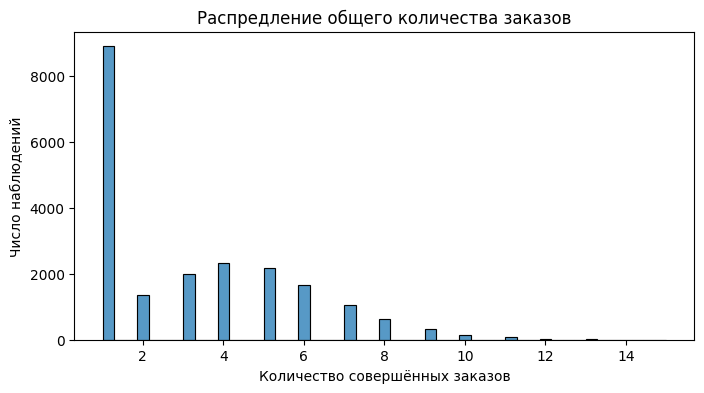

In [31]:
histplot(customers_df,
         'total_orders',
         "Распредление общего количества заказов",
         "Количество совершённых заказов",
         "Число наблюдений")

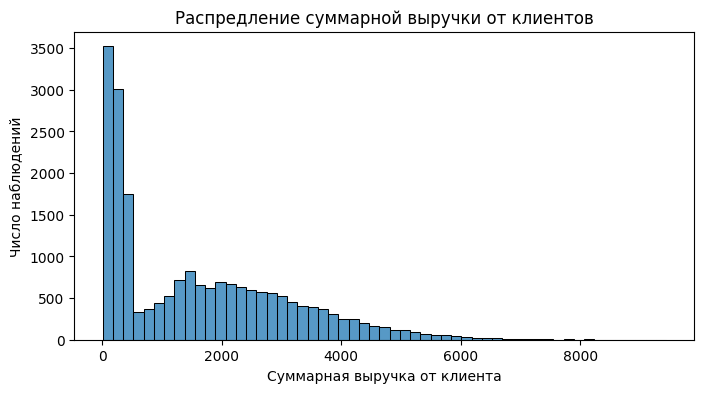

In [32]:
histplot(customers_df,
         'total_sales',
         "Распредление суммарной выручки от клиентов",
         "Суммарная выручка от клиента",
         "Число наблюдений")

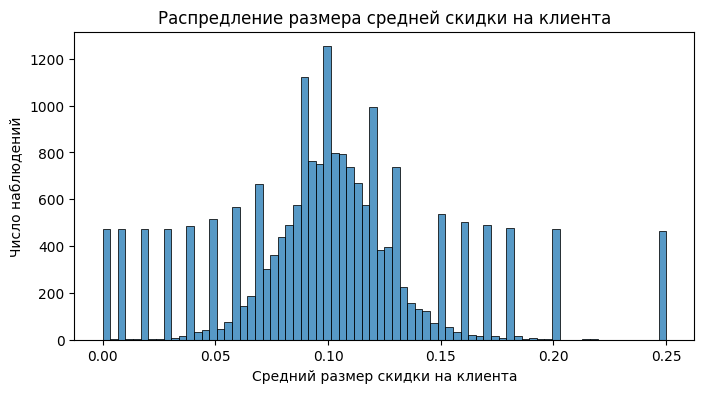

In [33]:
histplot(customers_df,
         'avg_discount',
         "Распредление размера средней скидки на клиента",
         "Средний размер скидки на клиента",
         "Число наблюдений")

<Figure size 800x400 with 0 Axes>

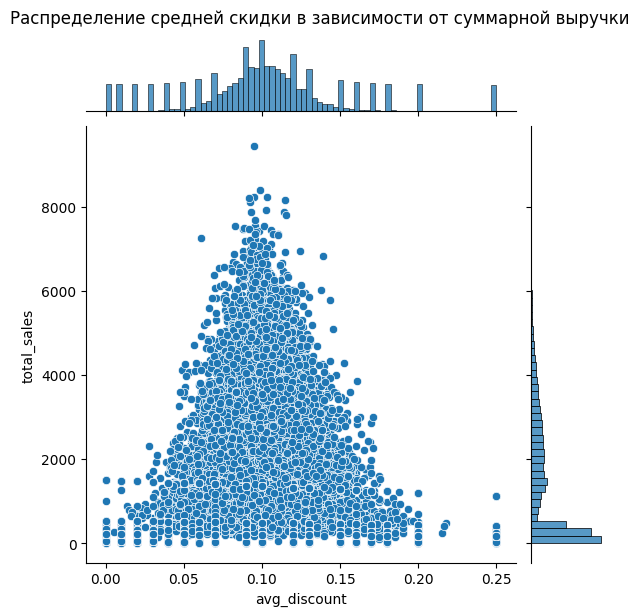

In [34]:
fig = plt.figure(figsize=(8, 4))
joint = sns.jointplot(
    data=customers_df,
    x='avg_discount',
    y='total_sales'
)
fig = joint.figure
fig.suptitle('Распределение средней скидки в зависимости от суммарной выручки', y=1.02)
plt.show()

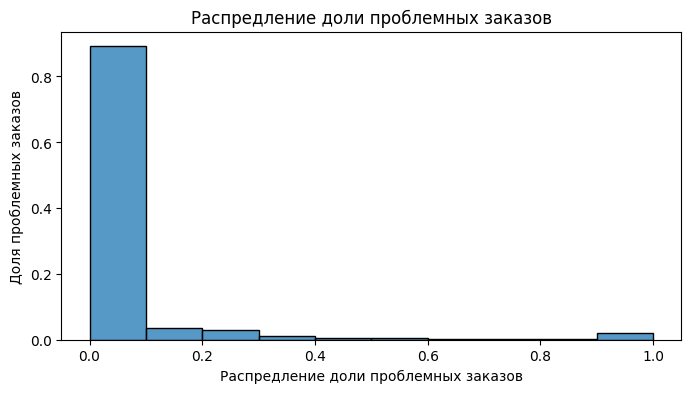

In [35]:
plt.figure(figsize=(8, 4))
sns.histplot(data=customers_df, x='return_rate', stat="probability", bins=10)
plt.xlabel("Распредление доли проблемных заказов")
plt.ylabel("Доля проблемных заказов")
plt.title("Распредление доли проблемных заказов")
plt.xticks(rotation=0)
plt.show()

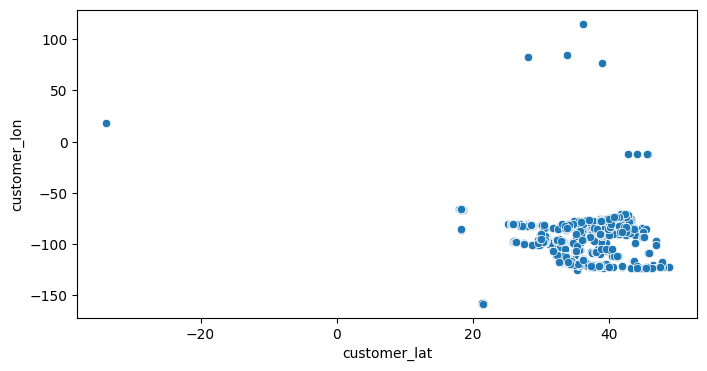

In [36]:
plt.figure(figsize=(8, 4))
sns.scatterplot(
    data=customers_df,
    x='customer_lat',
    y='customer_lon'
)
plt.show()

На графике рассеяния хорошо виден "цифровой шум" который необходимо удалить

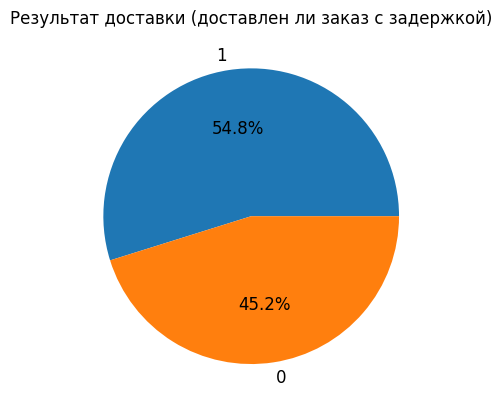

In [39]:
pie_diagram(orders_df['late_delivery_risk'].value_counts().index,
            orders_df['late_delivery_risk'].value_counts().values,
            'Результат доставки (доставлен ли заказ с задержкой)')

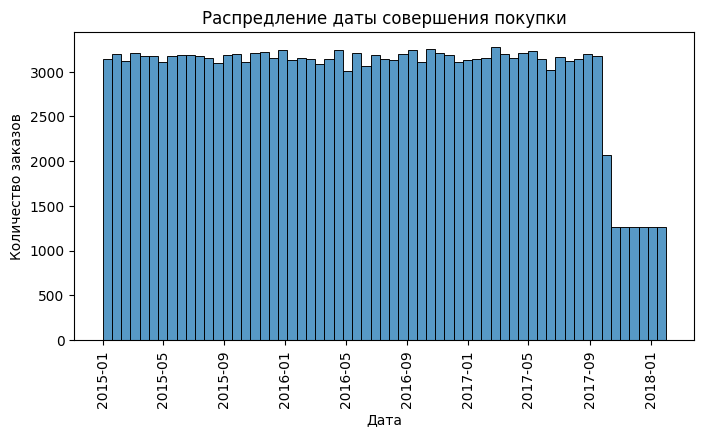

In [41]:
histplot(orders_df,
         'order_date',
         "Распредление даты совершения покупки",
         "Дата",
         "Количество заказов",
         rotation=90)

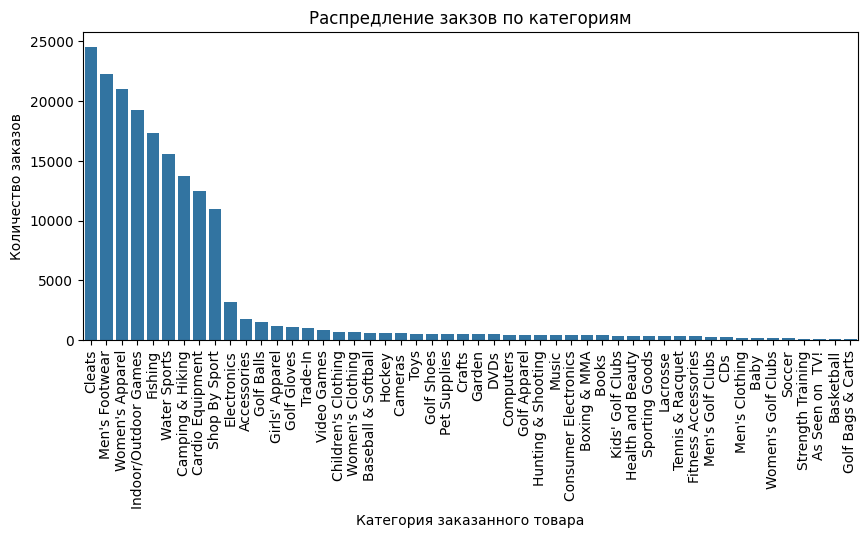

In [42]:
grouped_by_category_name = orders_df.groupby('category_name')['order_id'].count().reset_index().sort_values(by='order_id', ascending=False)

plt.figure(figsize=(10, 4))
sns.barplot(data=grouped_by_category_name, x='category_name', y='order_id')
plt.xlabel("Категория заказанного товара")
plt.ylabel("Количество заказов")
plt.title("Распредление закзов по категориям")
plt.xticks(rotation=90)
plt.show()

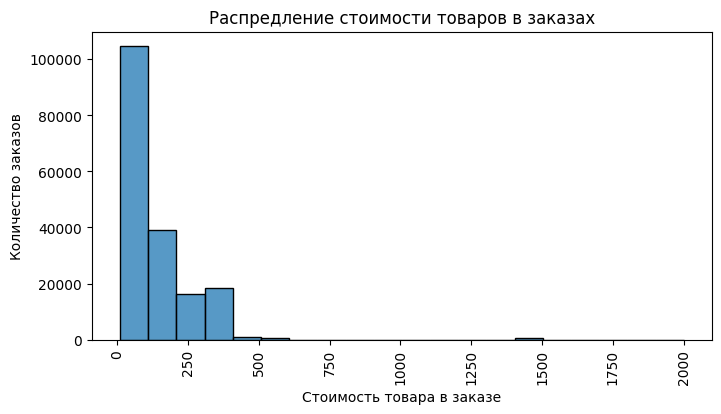

In [43]:
histplot(orders_df,
         'item_price',
         "Распредление стоимости товаров в заказах",
         "Стоимость товара в заказе",
         "Количество заказов",
         rotation=90,
         bins=20)

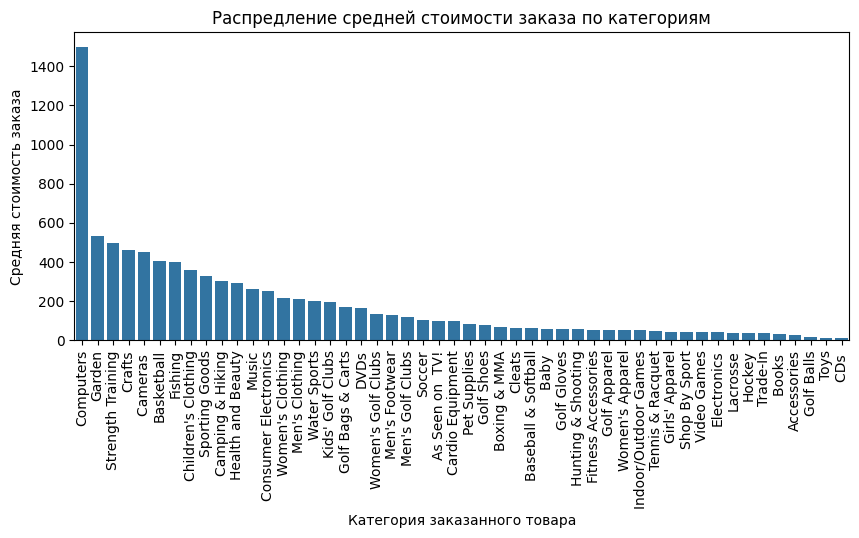

In [44]:
grouped_by_category_name = orders_df.groupby('category_name')['item_price'].mean().reset_index().sort_values(by='item_price', ascending=False)

plt.figure(figsize=(10, 4))
sns.barplot(data=grouped_by_category_name, x='category_name', y='item_price')
plt.xlabel("Категория заказанного товара")
plt.ylabel("Средняя стоимость заказа")
plt.title("Распредление средней стоимости заказа по категориям")
plt.xticks(rotation=90)
plt.show()

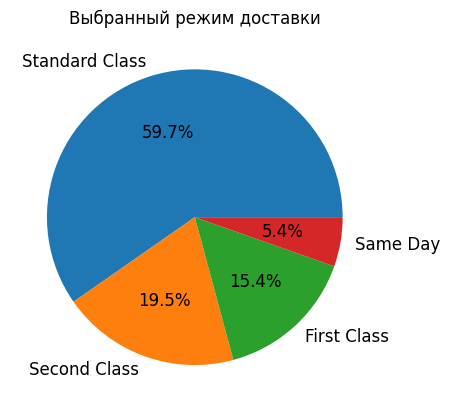

In [45]:
pie_diagram(orders_df['shipping_mode'].value_counts().index,
            orders_df['shipping_mode'].value_counts().values,
            'Выбранный режим доставки')

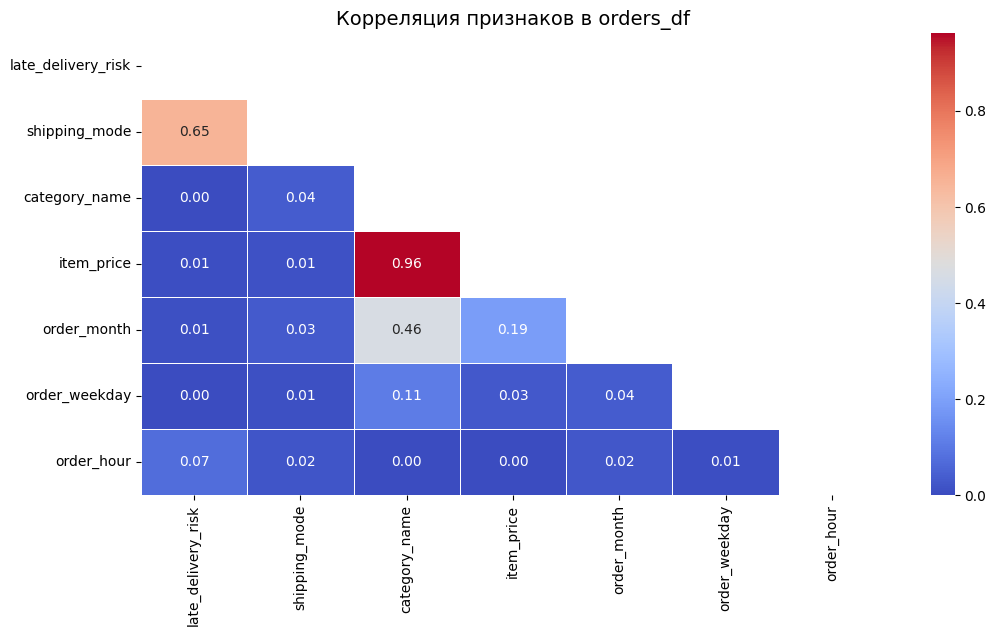

In [46]:
# Корреляция
interval_cols = ['late_delivery_risk', 'item_price', 'order_month', 'order_weekday', 'order_hour']

corr_data = orders_df.drop(columns=['order_id', 'customer_id', 'order_date']).phik_matrix(interval_cols=interval_cols)

plt.figure(figsize=(12, 6))
mask = np.triu(np.ones_like(corr_data, dtype=bool))
sns.heatmap(data=corr_data, annot=True,
            fmt='.2f', linewidths=0.5,
            cmap='coolwarm', mask=mask,)
plt.title('Корреляция признаков в orders_df', fontsize=14)
plt.show()

При анализе корреляции в таблице orders обнаружена высокая, почти идеальная корреляция между признаками item_price и category_name
Также сразу бросается в глаза выраженная связь между shipping_mode и late_delivery_risk, т.е. в данных есть признак, который явно связан с целевой переменной

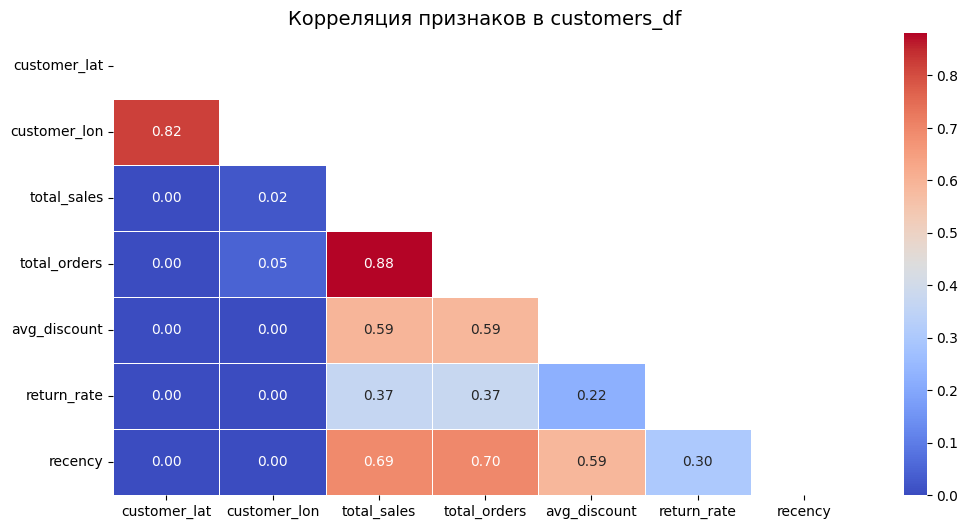

In [49]:
# Корреляция
interval_cols = ['customer_lat', 'customer_lon', 'total_sales', 'total_orders', 'avg_discount', 'return_rate', 'recency']

corr_data = customers_df.drop(columns='customer_id').phik_matrix(interval_cols=interval_cols)

plt.figure(figsize=(12, 6))
mask = np.triu(np.ones_like(corr_data, dtype=bool))
sns.heatmap(data=corr_data, annot=True,
            fmt='.2f', linewidths=0.5,
            cmap='coolwarm', mask=mask,)
plt.title('Корреляция признаков в customers_df', fontsize=14)
plt.show()

При анализе корреляции в таблице customers обнаружена высокая корреляция между призками total_sales и total_orders, а также между признаками customer_lon и customer_lat  
Стоит отметить умеренную корреляцию между recency и total_sales, а также recency и total_orders

In [55]:
# Фильтрация по географических данным
customers_df = customers_df[(customers_df['customer_lon'] >= -125) & (customers_df['customer_lon'] <= -20) &
    (customers_df['customer_lat'] <= 50) & (customers_df['customer_lat'] > 20)]

In [56]:
# Смотрим что получилось после фильтрации
print(f"Количество уникальных customer_id в customers: {customers_df['customer_id'].nunique()}")
print(f"Количество уникальных customer_id в orders: {orders_df['customer_id'].nunique()}")

intersection = set(orders_df['customer_id']) & set(customers_df['customer_id'])
print(f"Количество перескающихся customer_id в таблицах: {len(intersection)}")

Количество уникальных customer_id в customers: 12627
Количество уникальных customer_id в orders: 20652
Количество перескающихся customer_id в таблицах: 12627


In [57]:
orders_df = orders_df[orders_df['customer_id'].isin(intersection)]

In [59]:
orders_df.info()

<class 'pandas.DataFrame'>
Index: 110286 entries, 2 to 180516
Data columns (total 10 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   order_id            110286 non-null  int64         
 1   customer_id         110286 non-null  int64         
 2   late_delivery_risk  110286 non-null  int64         
 3   shipping_mode       110286 non-null  str           
 4   category_name       110286 non-null  str           
 5   order_date          110286 non-null  datetime64[us]
 6   item_price          110286 non-null  float64       
 7   order_month         110286 non-null  int32         
 8   order_weekday       110286 non-null  int32         
 9   order_hour          110286 non-null  int32         
dtypes: datetime64[us](1), float64(1), int32(3), int64(3), str(2)
memory usage: 10.7 MB


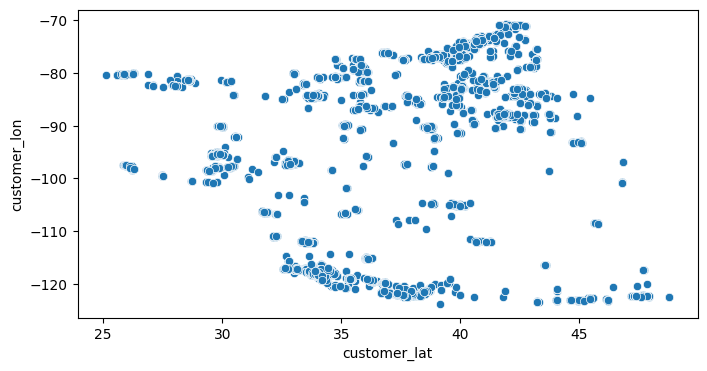

In [60]:
# Проверка что осталось в координатах
plt.figure(figsize=(8, 4))
sns.scatterplot(
    data=customers_df,
    x='customer_lat',
    y='customer_lon'
)
plt.show()

In [61]:
customers_df.info()

<class 'pandas.DataFrame'>
Index: 12627 entries, 0 to 20651
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   customer_id   12627 non-null  int64  
 1   customer_lat  12627 non-null  float64
 2   customer_lon  12627 non-null  float64
 3   total_sales   12627 non-null  float64
 4   total_orders  12627 non-null  int64  
 5   avg_discount  12627 non-null  float64
 6   return_rate   12627 non-null  float64
 7   recency       12627 non-null  int64  
dtypes: float64(5), int64(3)
memory usage: 887.8 KB


Выводы по данным:
  - Подавляющая часть клиентов имееют только 1 заказ
  - Чаще всего суммарная выручка от клиента не превосходит нескольких сотен
  - Средняя скидка клиентов варируется от 5 до 15% процентов
  - Проблемные заказы являются радкостью
  - Подтверждается распределение классов в целевой переменной в отношении 55% к 45%
  - С осени 2017 года количество заказов сократилось вдвое
  - Наиболее популярными являются следующие категории товаров:
      * Cleats
      * Men's Footwear
      * Women's Apparel
      * Indoor/Outdoor Games
      * Fishing
      * Water Sports
      * Camping & Hiking
      * Cardio Equipment
      * Shop By Sport
  - Чаще всего стоимость заказа не превосходит 100
  - Наиболее "дорогой" категорией является Computers
  - Самым попурялрым режимом доставки является Standard Class - на него приходится 59.7% заказов, на Second Class - 19.5%, First Class - 15.4%, Same Day самая редкая - 5.4%
  - При анализе корреляции в таблице orders обнаружена высокая корреляция между признаками item_price и category_name
  - При анализе корреляции в таблице customers обнаружена высокая корреляция между призками total_sales и total_orders, а также между признаками customer_lon и customer_lat
  - Из таблицы orders были удалены заказы с выбросами в координатах, выбросами считаются заказы, координаты которых выходят за пределы диапазона от -125 до -20 по широте или выходят за пределы от 20 до 50 по долготе
  - Количество перескающихся пользователей из таблицы orders и таблицы customers составило 12_627, таким образом, количество уникальных клиентов в таблице orders было урезано до 12_627
  - После всех преобразований в таблице orders осталось 110_286 строк, в таблице customers - 12_627 строк

##  Разделение на выборки

In [66]:
groups = orders_df['customer_id']
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_SEED)

In [67]:
t_idx, test_idx = next(gss.split(orders_df, groups=groups))

df_t = orders_df.iloc[t_idx]
df_orders_test = orders_df.iloc[test_idx]

In [68]:
groups_t = groups.iloc[t_idx]

In [69]:
gss2 = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=RANDOM_SEED)

In [70]:
train_orders_idx, val_orders_idx = next(gss2.split(df_t, groups=groups_t))

df_orders_train = df_t.iloc[train_orders_idx]
df_orders_val = df_t.iloc[val_orders_idx]

In [71]:
print(f"Количество строк в train: {df_orders_train.shape[0]} ({df_orders_train.shape[0] / orders_df.shape[0] * 100 :.2f})%")
print(f"Количество строк в train: {df_orders_val.shape[0]} ({df_orders_val.shape[0] / orders_df.shape[0] * 100 :.2f})%")
print(f"Количество строк в train: {df_orders_test.shape[0]} ({df_orders_test.shape[0] / orders_df.shape[0] * 100 :.2f})%")

Количество строк в train: 65748 (59.62)%
Количество строк в train: 22233 (20.16)%
Количество строк в train: 22305 (20.22)%


In [72]:
print(f"Количество клиентов из train в val: {df_orders_train['customer_id'].isin(df_orders_val['customer_id']).sum()}")
print(f"Количество клиентов из train в test: {df_orders_val['customer_id'].isin(df_orders_test['customer_id']).sum()}")
print(f"Количество клиентов из val в test: {df_orders_val['customer_id'].isin(df_orders_test['customer_id']).sum()}")

Количество клиентов из train в val: 0
Количество клиентов из train в test: 0
Количество клиентов из val в test: 0


In [73]:
# Деление датафрейма customers_df
df_customers_train = customers_df[customers_df['customer_id'].isin(df_orders_train['customer_id'])]
df_customers_val = customers_df[customers_df['customer_id'].isin(df_orders_val['customer_id'])]
df_customers_test = customers_df[customers_df['customer_id'].isin(df_orders_test['customer_id'])]

In [74]:
print(f"Количество строк в train: {df_customers_train.shape[0]} ({df_customers_train.shape[0] / customers_df.shape[0] * 100 :.2f})%")
print(f"Количество строк в train: {df_customers_val.shape[0]} ({df_customers_val.shape[0] / customers_df.shape[0] * 100 :.2f})%")
print(f"Количество строк в train: {df_customers_test.shape[0]} ({df_customers_test.shape[0] / customers_df.shape[0] * 100 :.2f})%")

Количество строк в train: 7575 (59.99)%
Количество строк в train: 2526 (20.00)%
Количество строк в train: 2526 (20.00)%


In [75]:
print(f"Количество клиентов из train в val: {df_customers_train['customer_id'].isin(df_customers_val['customer_id']).sum()}")
print(f"Количество клиентов из train в test: {df_customers_train['customer_id'].isin(df_customers_test['customer_id']).sum()}")
print(f"Количество клиентов из val в test: {df_customers_val['customer_id'].isin(df_customers_test['customer_id']).sum()}")

Количество клиентов из train в val: 0
Количество клиентов из train в test: 0
Количество клиентов из val в test: 0


## Обучение базовой модели

Прежде чем проверять гипотезу о сегментации и создавать при помощи кластеризации новые признаки, необходимо зафиксировать точку отсчёта. Вам нужно понять, какое качество прогноза задержек обеспечивают стандартные модели, используя только базовую информацию о самом заказе.

1. Выберите нужные признаки — используйте колонки таблицы `orders` (`shipping_mode`, `category_name`, `item_price`, `order_hour`,  `order_weekday` и `order_month`).

2. Обучите логистическую регрессию и `CatBoostClassifier` и оцените их качество.

3. Оцените качество обеих моделей на валидационной выборке.

Напоминаем, что на этапе построения базовой модели глубокий подбор гиперпараметров необязателен.

**Дополнительное задание.** Если вы чувствуете в себе силы, вы можете попробовать базовую оптимизацию, но помните: главная прибавка к качеству ожидается от новых признаков, которые вы создадите в следующих разделах.






In [79]:
X_train_base = df_orders_train[['shipping_mode', 'category_name',
              'item_price', 'order_hour',
              'order_weekday', 'order_month']]
y_train = df_orders_train['late_delivery_risk']


X_val_base = df_orders_val[['shipping_mode', 'category_name',
              'item_price', 'order_hour',
              'order_weekday', 'order_month']]
y_val = df_orders_val['late_delivery_risk']


X_test_base = df_orders_test[['shipping_mode', 'category_name',
              'item_price', 'order_hour',
              'order_weekday', 'order_month']]
y_test = df_orders_test['late_delivery_risk']

cat_features = ['shipping_mode', 'category_name', 'order_hour', 'order_weekday', 'order_month']
num_features = list(set(X_train_base.columns) - set(cat_features))

In [82]:
linear_preprocessor = ColumnTransformer(
    transformers=[
        ('categorical', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_features),
        ('numerical', StandardScaler(), num_features)
    ]
)
linear_pipeline = Pipeline(steps=[
    ('preprocessor', linear_preprocessor),
    ('model', LogisticRegression(random_state=RANDOM_SEED))
])

boosting_pipeline = Pipeline(steps=[
    ('model', CatBoostClassifier(random_state=RANDOM_SEED, cat_features=cat_features))
])

In [85]:
linear_pipeline.fit(X_train_base, y_train)
boosting_pipeline.fit(X_train_base, y_train)

y_pred_linear = linear_pipeline.predict_proba(X_val_base)[:, 1]
y_pred_boosting = boosting_pipeline.predict_proba(X_val_base)[:, 1]

Learning rate set to 0.061542
0:	learn: 0.6751496	total: 228ms	remaining: 3m 48s
1:	learn: 0.6597913	total: 284ms	remaining: 2m 21s
2:	learn: 0.6467482	total: 347ms	remaining: 1m 55s
3:	learn: 0.6357585	total: 380ms	remaining: 1m 34s
4:	learn: 0.6198933	total: 433ms	remaining: 1m 26s
5:	learn: 0.6090767	total: 508ms	remaining: 1m 24s
6:	learn: 0.5973997	total: 584ms	remaining: 1m 22s
7:	learn: 0.5882866	total: 657ms	remaining: 1m 21s
8:	learn: 0.5813775	total: 730ms	remaining: 1m 20s
9:	learn: 0.5755051	total: 807ms	remaining: 1m 19s
10:	learn: 0.5715855	total: 846ms	remaining: 1m 16s
11:	learn: 0.5675284	total: 909ms	remaining: 1m 14s
12:	learn: 0.5625620	total: 1.06s	remaining: 1m 20s
13:	learn: 0.5592048	total: 1.14s	remaining: 1m 20s
14:	learn: 0.5566090	total: 1.21s	remaining: 1m 19s
15:	learn: 0.5541486	total: 1.27s	remaining: 1m 18s
16:	learn: 0.5522739	total: 1.34s	remaining: 1m 17s
17:	learn: 0.5502208	total: 1.41s	remaining: 1m 16s
18:	learn: 0.5481492	total: 1.47s	remaining:

In [86]:
print("Метрики LogisticRegression на валидационной выборке\n")
print(f"ROC_AUC: {roc_auc_score(y_val, y_pred_linear):.3f}")

Метрики LogisticRegression на валидационной выборке

ROC_AUC: 0.740


In [87]:
print("Метрики CatBoost на валидационной выборке\n")
print(f"ROC_AUC: {roc_auc_score(y_val, y_pred_boosting):.3f}")

Метрики CatBoost на валидационной выборке

ROC_AUC: 0.776


Обе базовые модели демонстрируют высокие показатели ROC_AUC, близкие к целевому 0.75
  * для модели Логистической регрессии : 0.74
  * для CatBoost : 0.776

##  Кластеризация по признакам, связанным с местоположением



На этом этапе нужно превратить исходные координаты `customer_lat` и `customer_lon` в полезный для модели признак — логистическую зону.

**Ваши действия:**

1. Проведите корректную подготовку признаков.
2. Продумайте защиту от утечки данных.
3. Используйте метод локтя, чтобы найти математически обоснованную границу количества групп.
4. Постройте график с полученными кластерами и отметьте центроиды.

In [93]:
coords = df_customers_train[['customer_lat', 'customer_lon']].values

In [94]:
scaler_geo = StandardScaler()
scaled_values = scaler_geo.fit_transform(coords)

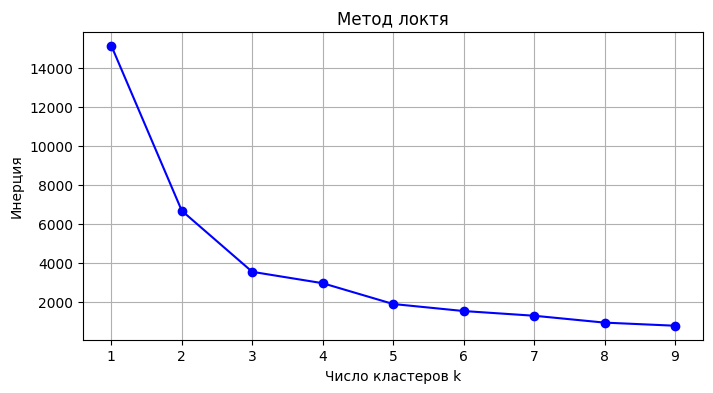

In [95]:
inertias = []
K_range = range(1, 10)
for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=RANDOM_SEED)
    kmeans.fit(scaled_values)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertias, 'bo-')
plt.xlabel('Число кластеров k')
plt.ylabel('Инерция')
plt.title('Метод локтя')
plt.grid(True)
plt.show()

In [97]:
optimal_k = 3
kmeans_geo = KMeans(n_clusters=optimal_k, random_state=RANDOM_SEED)
train_labels = kmeans_geo.fit_predict(scaled_values)

In [98]:
train_lat = coords[:, 0]
train_lon = coords[:, 1]

centroids_scaled = kmeans_geo.cluster_centers_
centroids_original = scaler_geo.inverse_transform(centroids_scaled)
centroids_lat = centroids_original[:, 0]
centroids_lon = centroids_original[:, 1]

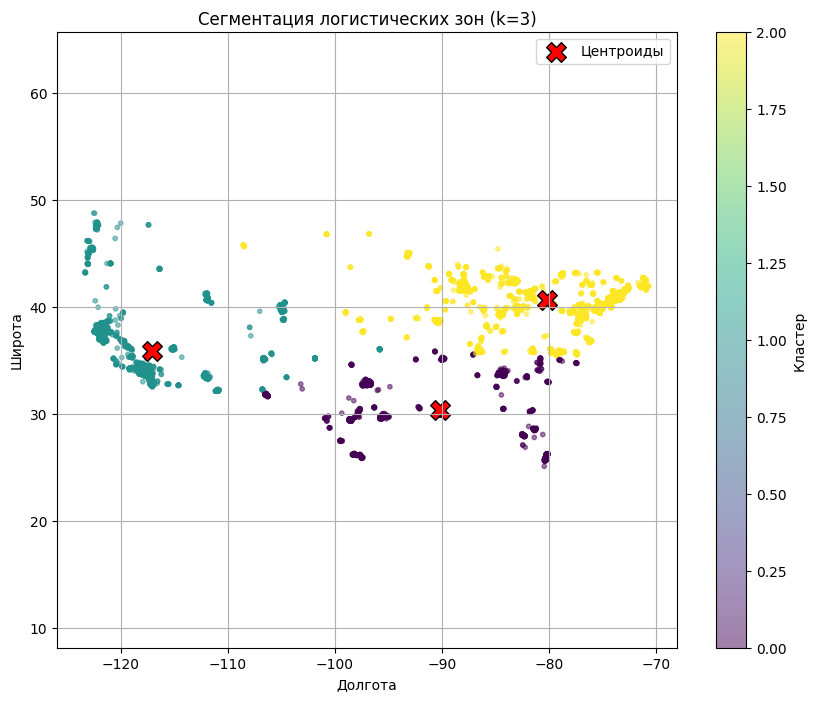

In [99]:
plt.figure(figsize=(10, 8))
scatter = plt.scatter(train_lon, train_lat, c=train_labels, cmap='viridis', s=10, alpha=0.5)
plt.scatter(centroids_lon, centroids_lat, c='red', marker='X', s=200, 
            edgecolors='black', label='Центроиды')
plt.xlabel('Долгота')
plt.ylabel('Широта')
plt.title(f'Сегментация логистических зон (k={optimal_k})')
plt.legend()
plt.colorbar(scatter, label='Кластер')
plt.grid(True)
plt.axis('equal')
plt.show()

В результате кластеризации клиентов по кооринатам было выделено 3 кластера, которые визуально также отделимы

##  Кластеризация по признакам профилей клиентов





1. Подготовьте векторы признаков — используйте пять ключевых показателей из датасета `df_customers.csv`: `recency`, `total_orders`, `total_sales`, `return_rate` и `avg_discount`.
2. Выполните предобработку данных и обеспечьте защиту от утечек.
3. Используйте метод локтя, чтобы найти математически обоснованную границу количества групп.
4. Проанализируйте полученные кластеры: дайте статистическую характеристику и опишите самые яркие группы.
5. Визуализируйте положение кластеров с помощью t-SNE.



In [104]:
cutted_customers = df_customers_train[['recency', 'total_orders',
                                 'total_sales', 'return_rate',
                                 'avg_discount']]

In [105]:
scale_rfm = StandardScaler()
cutted_customers_scaled = scale_rfm.fit_transform(cutted_customers)

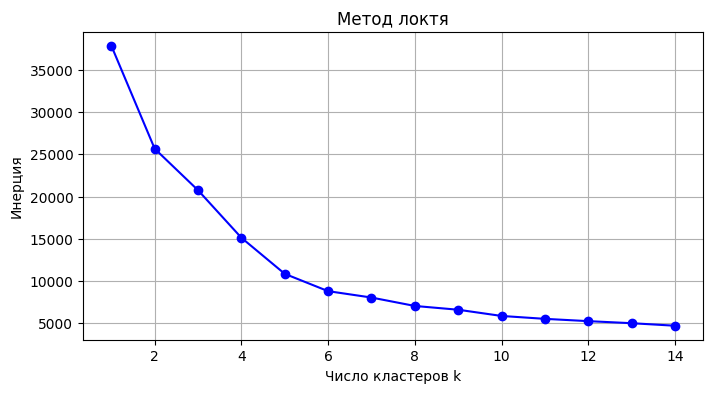

In [107]:
inertias = []
K_range = range(1, 15)
for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=RANDOM_SEED)
    kmeans.fit(cutted_customers_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertias, 'bo-')
plt.xlabel('Число кластеров k')
plt.ylabel('Инерция')
plt.title('Метод локтя')
plt.grid(True)
plt.show()

In [108]:
optimal_k = 5
kmeans_rfm = KMeans(n_clusters=optimal_k, random_state=RANDOM_SEED)
train_labels = kmeans_rfm.fit_predict(cutted_customers_scaled)

In [109]:
cutted_customers['client_profile'] = train_labels

In [110]:
cutted_customers.groupby('client_profile').mean()

,recency,total_orders,total_sales,return_rate,avg_discount
client_profile,,,,,
0,503.939873,3.113291,1565.651524,0.022876,0.101629
1,76.224363,1.126635,317.764096,0.001317,0.166746
2,239.295445,6.013301,3337.207332,0.045480,0.102007
3,178.120879,1.538462,629.702643,0.887116,0.100370
4,76.269824,1.176690,378.272152,0.000829,0.050437


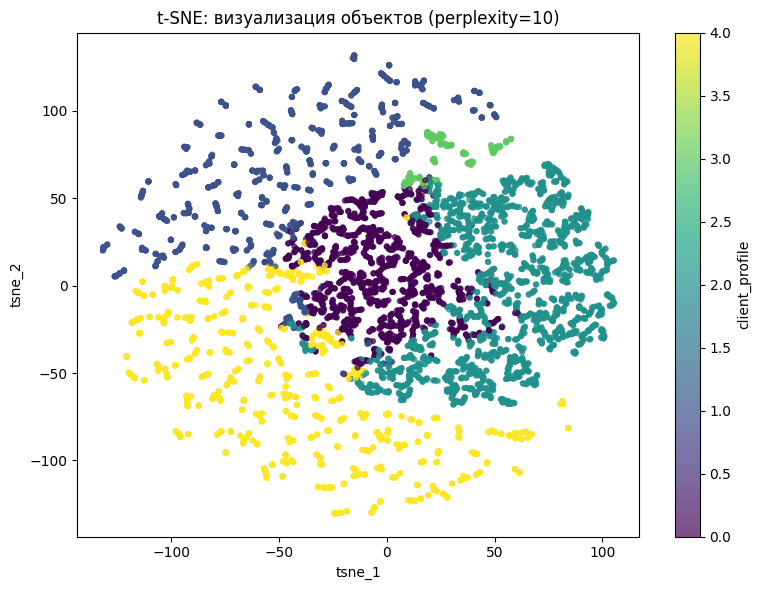

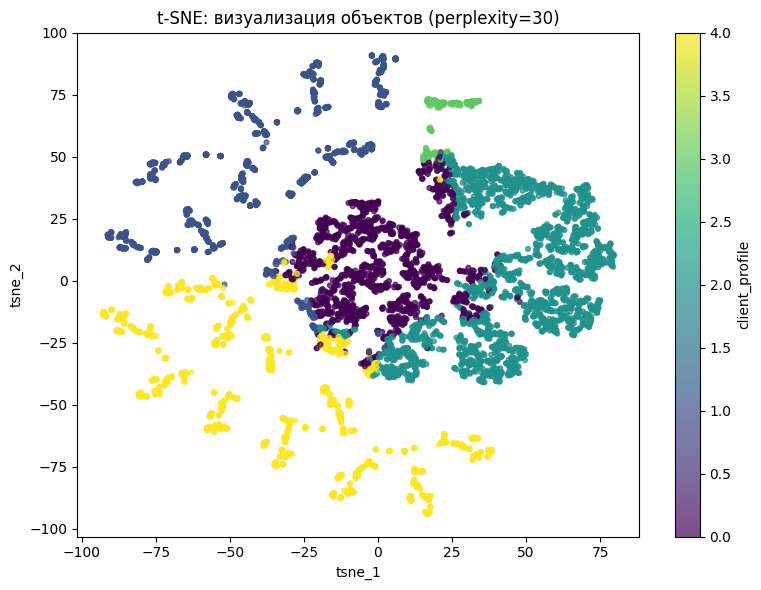

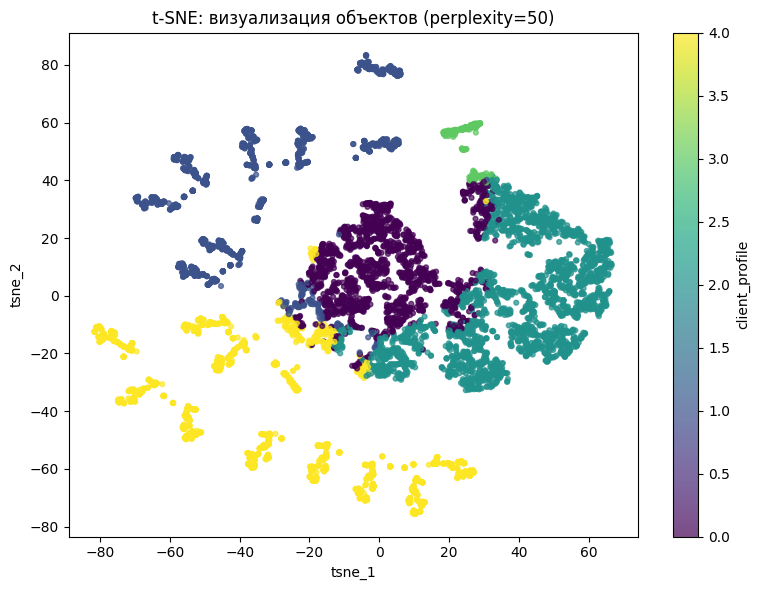

In [111]:
perplexities = [10, 30, 50]

for perplexity in perplexities:
    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        init="pca",
        random_state=RANDOM_SEED,
        learning_rate="auto"
    )
    
    customers_tsne = tsne.fit_transform(cutted_customers_scaled)
    
    tsne_df = pd.DataFrame(customers_tsne, columns=["tsne_1", "tsne_2"])
    
    color_values = cutted_customers["client_profile"].values
    tsne_df["client_profile"] = color_values
    
    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(
        tsne_df["tsne_1"],
        tsne_df["tsne_2"],
        c=tsne_df["client_profile"],
        s=12,
        alpha=0.7,
    )
    
    plt.title(f"t-SNE: визуализация объектов (perplexity={perplexity})")
    plt.xlabel("tsne_1")
    plt.ylabel("tsne_2")
    plt.colorbar(scatter, label="client_profile")
    
    plt.tight_layout()
    plt.show()

Комментарии по графикам:
  - При каждом выбранном perplexity в данных хорошо видны кластеры профиля клиентов, т.е. их видно как при анализе локальной структуры, так и более глобальной. Такой сигнал может свидетельствовать о реальности полученных кластеров
  - При perplexity равном 50 можно также обнаружить, что они состоят из еще меньших кластеров внутри себя. Однако, в связи с низкой эффективности дальнейшего разделения, было решено остановиться на 5 кластерах
  - Наименьшим кластером является 3, т.е. клиенты с высокой долей проблемных заказов
  - Наиболее плотными являются кластеры 0 и 2
  - На основании полученных проекций можно сделать вывод о том, что выбранное количество кластеров, а именно 5, являтся вполне адекватным значением. 

Клиенты были разделены на 5 кластеров:
  * Пользоватлей в 0 кластере можно назвать лояльными клиентами с редкими заказами
  * Пользователей в 1 кластере характеризуются высокой скидкой, низкой суммарной выручкой и малым количеством заказов, скорее всего это люди которые один раз воспольовались каким-либо промокодом или скидкой и больше никогда не заказывали
  * Пользователи во 2 кластере являются наиболее лояльными - у них больше всего среднее количество заказов, высокая суммарная выручка от заказов и значение recenty на уровне около среднего по всем кластерам
  * Пользователей в 3 кластере можно назвать недовольными клиентами, процент проблемных заказов в них ~88%, такие пользователи имеют малое количество заказов
  * Пользователи в 4 кластере очень похожи на пользователей из 1 кластера, но здесь явно выделяется средний размер скидки, если пользователи из 1 кластера скорее всего пришли по какой-то акции, то здесь пользователи пришли сами

##  Обучение модели на новых признаках

1. Добавьте результаты кластеризаций в данные для обучения моделей.
2. Обучите финальные версии логистической регрессии и `CatBoostClassifier` на расширенном наборе данных.
3. Рассчитайте итоговые значения метрики ROC−AUC на валидационной выборке.
   

In [121]:
X_train_base = df_orders_train.merge(
    df_customers_train,
    on='customer_id',
    how='left',
    suffixes=('', '_cus')
)

X_val_base = df_orders_val.merge(
    df_customers_val,
    on='customer_id',
    how='left',
    suffixes=('', '_cus')
)

X_test_base = df_orders_test.merge(
    df_customers_test,
    on='customer_id',
    how='left',
    suffixes=('', '_cus')
)

In [122]:
cols = ['recency', 'total_orders', 
      'total_sales', 'return_rate',
      'avg_discount', 'shipping_mode',
      'category_name', 'item_price',
      'order_hour', 'order_weekday',
      'order_month', 'customer_lat',
      'customer_lon']

geo_cols = ['customer_lat', 'customer_lon']
rfm_cols = ['recency', 'total_orders', 'total_sales', 'return_rate','avg_discount']

In [123]:
X_train = X_train_base[cols]
# Добавление геокластера
X_train['geo_cluster'] = kmeans_geo.predict(scaler_geo.transform(X_train[geo_cols]))
X_train = X_train.drop(columns=geo_cols)
# Добавление кластера пользователя
X_train['rfm_cluster'] = kmeans_rfm.predict(scale_rfm.transform(X_train[rfm_cols]))
X_train = X_train.drop(columns=rfm_cols)


X_val = X_val_base[cols]
# Добавление геокластера
X_val['geo_cluster'] = kmeans_geo.predict(scaler_geo.transform(X_val[geo_cols]))
X_val = X_val.drop(columns=geo_cols)
# Добавление кластера пользователя
X_val['rfm_cluster'] = kmeans_rfm.predict(scale_rfm.transform(X_val[rfm_cols]))
X_val = X_val.drop(columns=rfm_cols)


X_test = X_test_base[cols]
# Добавление геокластера
X_test['geo_cluster'] = kmeans_geo.predict(scaler_geo.transform(X_test[geo_cols]))
X_test = X_test.drop(columns=geo_cols)
# Добавление кластера пользователя
X_test['rfm_cluster'] = kmeans_rfm.predict(scale_rfm.transform(X_test[rfm_cols]))
X_test = X_test.drop(columns=rfm_cols)

C:\Users\bekishev\AppData\Local\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\bekishev\AppData\Local\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\bekishev\AppData\Local\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


In [124]:
cat_features_new = ['shipping_mode', 'category_name', 'rfm_cluster', 'geo_cluster', 'order_hour', 'order_weekday', 'order_month']
num_features_new = list(set(X_train.columns) - set(cat_features))

In [125]:
preprocessor_linear_new = ColumnTransformer(transformers=[
    ('categorical', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), cat_features_new),
    ('numeric', StandardScaler(), num_features_new)
])

linear_pipeline_new = Pipeline(steps=[
    ('preprocessor', preprocessor_linear_new),
    ('model', LogisticRegression(random_state=RANDOM_SEED))
])

catboost_new = CatBoostClassifier(random_state=RANDOM_SEED, cat_features=cat_features_new)

In [126]:
linear_pipeline_new.fit(X_train, y_train)
catboost_new.fit(X_train, y_train)

Learning rate set to 0.061542
0:	learn: 0.6746071	total: 79.7ms	remaining: 1m 19s
1:	learn: 0.6585099	total: 150ms	remaining: 1m 14s
2:	learn: 0.6447450	total: 221ms	remaining: 1m 13s
3:	learn: 0.6331658	total: 296ms	remaining: 1m 13s
4:	learn: 0.6234493	total: 336ms	remaining: 1m 6s
5:	learn: 0.6151029	total: 378ms	remaining: 1m 2s
6:	learn: 0.6001470	total: 461ms	remaining: 1m 5s
7:	learn: 0.5899258	total: 541ms	remaining: 1m 7s
8:	learn: 0.5803738	total: 611ms	remaining: 1m 7s
9:	learn: 0.5731874	total: 667ms	remaining: 1m 6s
10:	learn: 0.5678396	total: 728ms	remaining: 1m 5s
11:	learn: 0.5624157	total: 807ms	remaining: 1m 6s
12:	learn: 0.5591348	total: 896ms	remaining: 1m 8s
13:	learn: 0.5559649	total: 954ms	remaining: 1m 7s
14:	learn: 0.5531721	total: 1.04s	remaining: 1m 8s
15:	learn: 0.5508773	total: 1.11s	remaining: 1m 8s
16:	learn: 0.5487974	total: 1.17s	remaining: 1m 7s
17:	learn: 0.5465256	total: 1.24s	remaining: 1m 7s
18:	learn: 0.5447125	total: 1.31s	remaining: 1m 7s
19:	le

CatBoostClassifier(cat_features=['shipping_mode', 'category_name', 'rfm_cluster', 'geo_cluster', 'order_hour', 'order_weekday', 'order_month'], random_state=42)

In [127]:
y_pred_linear = linear_pipeline_new.predict_proba(X_val)[:, 1]
y_pred_boosting = catboost_new.predict_proba(X_val)[:, 1]

In [128]:
print("Метрики LogisticRegression на валидационной выборке\n")
print(f"ROC_AUC: {roc_auc_score(y_val, y_pred_linear):.3f}")

Метрики LogisticRegression на валидационной выборке

ROC_AUC: 0.743


In [131]:
print("Метрики CatBoost на валидационной выборке\n")
print(f"ROC_AUC: {roc_auc_score(y_val, y_pred_boosting):.3f}")

Метрики CatBoost на валидационной выборке

ROC_AUC: 0.768


In [132]:
param_grid = [
    {
        'model__C': [0.001, 0.01, 0.1, 1, 10, 100],
        'model__l1_ratio': [0],
        'model__solver': ['lbfgs'],
        'model__class_weight': [None, 'balanced'],
        'model__max_iter': [2000]
    },
    {
        'model__C': [0.001, 0.01, 0.1, 1, 10, 100],
        'model__l1_ratio': [0, 1],
        'model__solver': ['liblinear'],
        'model__class_weight': [None, 'balanced'],
        'model__max_iter': [2000]
    }
]

split_index = np.concatenate([
    np.full(len(X_train), -1),
    np.zeros(len(X_val))
])
ps = PredefinedSplit(split_index)

grid_search = GridSearchCV(linear_pipeline_new, param_grid, cv=ps, scoring='roc_auc')
grid_search.fit(pd.concat([X_train, X_val]), pd.concat([y_train, y_val]))

best_linear_model = grid_search.best_estimator_

In [136]:
def objective(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 100, 500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'depth': trial.suggest_int('depth', 4, 10),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-5, 10),
        'verbose': False,
        'random_seed': RANDOM_SEED,
        'allow_writing_files': False,
        'cat_features' : cat_features_new
    }
    
    tscv = TimeSeriesSplit(n_splits=3)
    scores = []
    
    for train_idx, val_idx in tscv.split(X_train):
        X_fold_train = X_train.iloc[train_idx]
        y_fold_train = y_train.iloc[train_idx]
        X_fold_val = X_train.iloc[val_idx]
        y_fold_val = y_train.iloc[val_idx]
        
        model = CatBoostClassifier(**params)
        model.fit(
            X_fold_train, y_fold_train,
            eval_set=(X_fold_val, y_fold_val),
            early_stopping_rounds=50,
            verbose=False
        )

        y_pred_proba = model.predict_proba(X_fold_val)[:, 1]
        score = roc_auc_score(y_fold_val, y_pred_proba)
        scores.append(score)
    return np.mean(scores)

In [137]:
sampler = optuna.samplers.TPESampler(seed=RANDOM_SEED)
study = optuna.create_study(direction='maximize', sampler=sampler)
study.optimize(objective, n_trials=10)

[I 2026-06-03 13:54:43,368] A new study created in memory with name: no-name-afb5fb04-18ce-41d0-9c1e-91da3d07bb56
[I 2026-06-03 13:55:11,843] Trial 0 finished with value: 0.8174632040513692 and parameters: {'iterations': 250, 'learning_rate': 0.28570714885887566, 'depth': 9, 'l2_leaf_reg': 5.9865888553855235}. Best is trial 0 with value: 0.8174632040513692.
[I 2026-06-03 13:55:20,785] Trial 1 finished with value: 0.7257404273968643 and parameters: {'iterations': 162, 'learning_rate': 0.055238410897498764, 'depth': 4, 'l2_leaf_reg': 8.661762795987894}. Best is trial 0 with value: 0.8174632040513692.
[I 2026-06-03 13:55:49,425] Trial 2 finished with value: 0.8098149218372294 and parameters: {'iterations': 341, 'learning_rate': 0.21534104756085318, 'depth': 4, 'l2_leaf_reg': 9.699098822521421}. Best is trial 0 with value: 0.8174632040513692.
[I 2026-06-03 13:56:38,033] Trial 3 finished with value: 0.8164526729091907 and parameters: {'iterations': 433, 'learning_rate': 0.07157834209670008,

In [138]:
best_params = study.best_params
best_boosting = CatBoostClassifier(**best_params, cat_features=cat_features_new)
best_boosting.fit(X_train, y_train)
y_proba_best_boosting = best_boosting.predict_proba(X_val)[:, 1]

0:	learn: 0.6774592	total: 68.6ms	remaining: 23.6s
1:	learn: 0.6636617	total: 133ms	remaining: 22.7s
2:	learn: 0.6516109	total: 206ms	remaining: 23.5s
3:	learn: 0.6367818	total: 277ms	remaining: 23.6s
4:	learn: 0.6240341	total: 336ms	remaining: 22.8s
5:	learn: 0.6114315	total: 403ms	remaining: 22.8s
6:	learn: 0.6011944	total: 462ms	remaining: 22.3s
7:	learn: 0.5934031	total: 556ms	remaining: 23.4s
8:	learn: 0.5868783	total: 616ms	remaining: 23s
9:	learn: 0.5813154	total: 688ms	remaining: 23.1s
10:	learn: 0.5748933	total: 756ms	remaining: 23s
11:	learn: 0.5707868	total: 827ms	remaining: 23s
12:	learn: 0.5674277	total: 895ms	remaining: 22.8s
13:	learn: 0.5637786	total: 954ms	remaining: 22.5s
14:	learn: 0.5605421	total: 1.02s	remaining: 22.5s
15:	learn: 0.5576128	total: 1.09s	remaining: 22.4s
16:	learn: 0.5546129	total: 1.15s	remaining: 22.2s
17:	learn: 0.5528243	total: 1.18s	remaining: 21.5s
18:	learn: 0.5503215	total: 1.27s	remaining: 21.7s
19:	learn: 0.5483062	total: 1.33s	remaining: 2

In [139]:
print("Метрики CatBoost на валидационной выборке\n")
print(f"ROC_AUC: {roc_auc_score(y_val, y_proba_best_boosting):.3f}")

Метрики CatBoost на валидационной выборке

ROC_AUC: 0.774


In [140]:
print("Метрики Логистической регрессии на валидационной выборке\n")
y_proba_linear_optz = best_linear_model.predict_proba(X_val)[:, 1]
print(f"ROC_AUC: {roc_auc_score(y_val, y_proba_linear_optz):.3f}")

Метрики Логистической регрессии на валидационной выборке

ROC_AUC: 0.749


Лучшей моделью оказалась CatBoost, при этом ROC_AUC от добавления новых признаков и подбора гиперпараметров незначительно улучшило ROC_AUC

## Тестирование лучшей модели

На этом этапе вы должны убедиться, что выбранная модель сохраняет высокое качество на данных, которые она никогда не видела, и понять, какие факторы стали решающими для прогноза.

1. Выполните предсказание на тестовой выборке для лучшей модели. Рассчитайте итоговый ROC-AUC и сравните его с целевым показателем 0.75.
2. Постройте матрицу ошибок. Определите, какой тип ошибок совершает модель чаще: пропускает ли она реальные задержки или слишком часто выдаёт ложную тревогу?
3. Визуализируйте важность признаков вашей лучшей модели.
4. Проанализируйте позиции созданных вами признаков `geo_cluster` и `beh_cluster` в общем рейтинге. Стали ли они ключевыми факторами для предсказаний модели для модели или базовые параметры заказа (цена, время) остались приоритетными?

In [146]:
y_proba_test = best_boosting.predict_proba(X_test)[:, 1]
y_pred_test = best_boosting.predict(X_test)
print("Метрики CatBoost на тестовой выборке\n")
print(f"ROC_AUC: {roc_auc_score(y_test, y_proba_test):.3f}")

Метрики CatBoost на тестовой выборке

ROC_AUC: 0.767


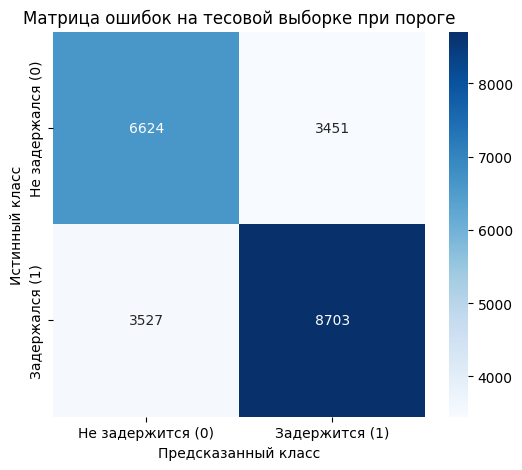

In [149]:
cm = confusion_matrix(y_test, y_pred_test)
tn, fp, fn, tp = cm.ravel()

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Не задержится (0)', 'Задержится (1)'],
            yticklabels=['Не задержался (0)', 'Задержался (1)'])
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.title(f'Матрица ошибок на тесовой выборке при пороге')
plt.show()

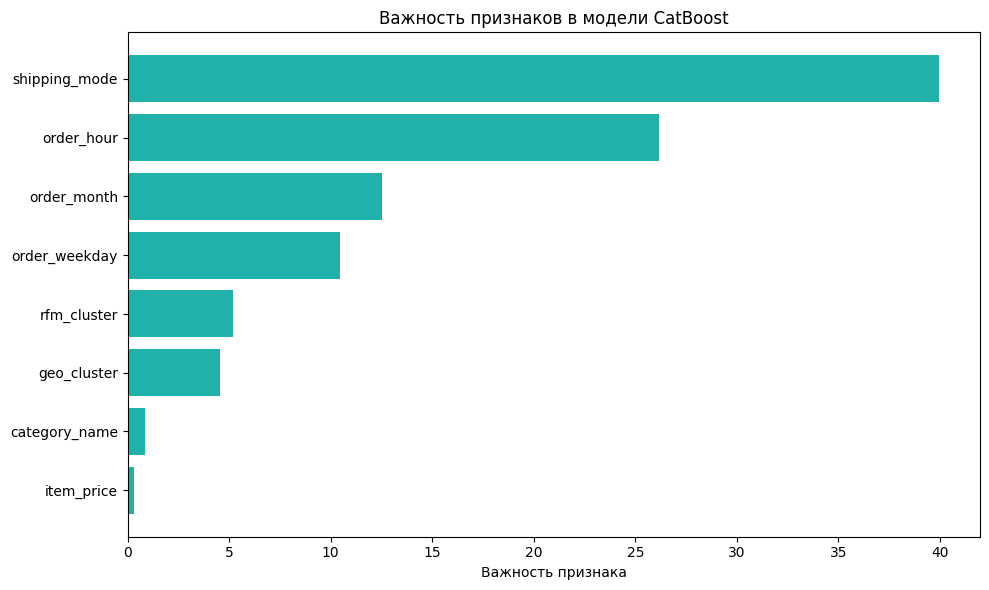

In [150]:
feature_importance = pd.DataFrame({
    "feature": X_test.columns,
    "importance": best_boosting.feature_importances_
}).sort_values("importance", ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(
    y=feature_importance["feature"][::-1],
    width=feature_importance["importance"][::-1],
    color='lightseagreen'
)
plt.xlabel("Важность признака")
plt.title("Важность признаков в модели CatBoost")
plt.tight_layout()
plt.show()

Выводы:
  - Модель CatBoost показывает стабильные результаты, ROC_AUC на всех выборках оставался примерно на одном уровне (в диапазоне 0.767 - 0.774)
  - В результате анализа матрицы ошибок на тестовой выборке можно сделать следующие выводы:
      * 65.2% заказов, которые были предсказаны как не задерживающиеся, в действительности являются таковыми, остальные 34.8% предсказаний модель определила неверно
      * 71.6% заказов, которые были предсказаны как задерживающиеся, действительно таковыми являются, остальные 28.4% модель определила неверно
  - Существуют 2 наиболее выделяющихся по важности для модели признака, которыми оказались тип доставки и час заказа. Сформированные кластерные признаки не показали себя "определяющими" для модели и вносят примерно одинаковый вклад

##  Выводы и рекомендации

Что нужно зафиксировать:

* **Результаты моделирования.** Укажите итоговое значение ROC-AUC на тестовой выборке. Удалось ли вам достичь целевого показателя? Насколько эффективно итоговая модель справляется с выявлением задержек по сравнению с базовыми?
* **Эффективность сегментации.** Сформулируйте вывод о полезности кластеризации. Подтвердилась ли гипотеза о том, что профиль клиента и его географическое положение влияют на риск задержки? Какие именно кластеры — географические или поведенческие — оказались более информативными для модели? Добавьте в раздел визуализации, которые вы получили, работая над проектом.
* **Технический инсайт.** Если вы экспериментировали с разным количеством  кластеров как с гиперпараметром, то укажите, какое количество кластеров K оказалось оптимальным. Кратко поясните, почему слишком большое K может вредить качеству прогноза.
* **Бизнес-рекомендации.** Предложите, как CargaPronto может использовать вашу модель в реальных операциях.

  - Итоговое значение ROC AUC на тестовой выборке составило 0.767 - Целевой показатель был достигнут
  - В результате анализа матрицы ошибок на тестовой выборке получилось следующее:
      * 65.2% заказов, которые были предсказаны как не задерживающиеся, в действительности являются таковыми, остальные 34.8% предсказаний модель определила неверно
      * 71.6% заказов, которые были предсказаны как задерживающиеся, действительно таковыми являются, остальные 28.4% модель определила неверно
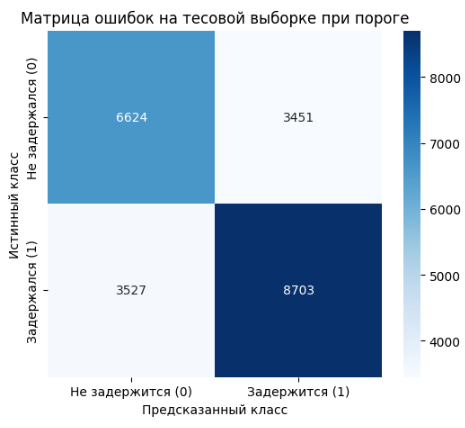
  - Сегментация пользователей как по геолокации, так и по профилю клиента не оказала существенного влияния на метрики модели
  - Существуют 2 наиболее выделяющихся по важности для модели признака, которыми оказались тип доставки и час заказа. Сформированные кластерные признаки не показали себя "определяющими" для модели и вносят примерно одинаковый вклад
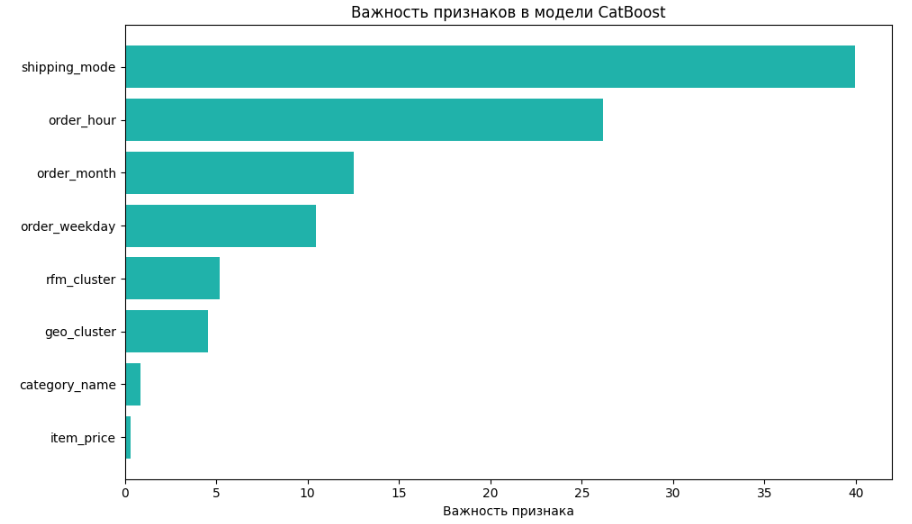